# **Decision Tree Classifier**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
)

np.random.seed(10)
plt.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

## **1. Load the Iris Dataset**

In [2]:
iris = load_iris()

print("Keys available:", list(iris.keys()))
print("\nFeature names:", iris.feature_names)
print("Target names  :", list(iris.target_names))
print("\nDataset description (first 400 chars):\n", iris.DESCR[:400])

Keys available: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Dataset description (first 400 chars):
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Ve


In [3]:
X = pd.DataFrame(iris.data, columns=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])
y = iris.target

print("X shape:", X.shape)
X.head()


X shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
print("Target encoding: 0 =", iris.target_names[0], "| 1 =", iris.target_names[1], "| 2 =", iris.target_names[2])
print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())

Target encoding: 0 = setosa | 1 = versicolor | 2 = virginica

Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


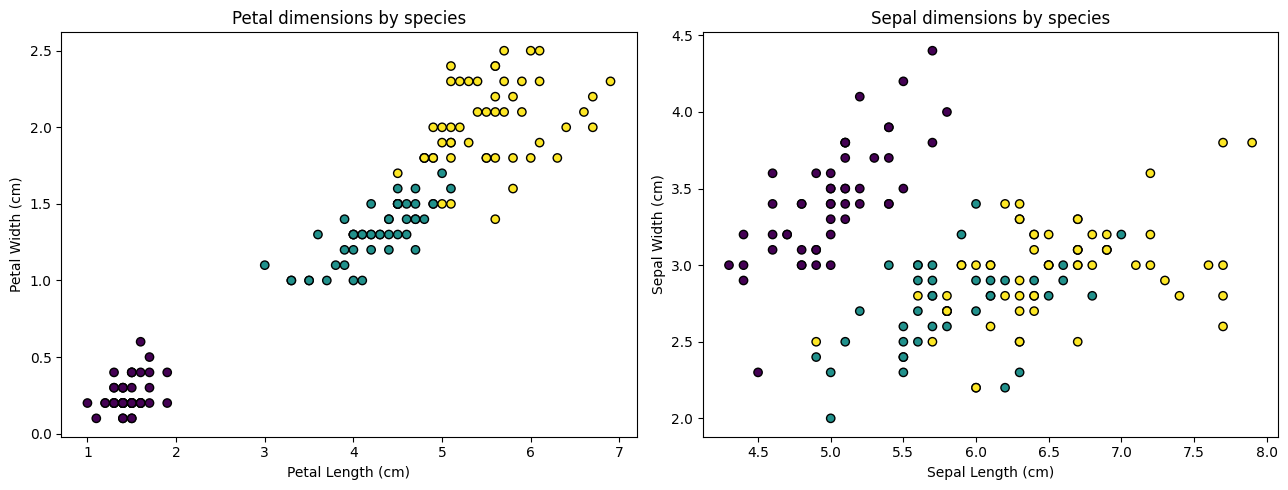

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X['petal length (cm)'], X['petal width (cm)'], c=y, cmap='viridis', edgecolor='k')
axes[0].set_xlabel('Petal Length (cm)'); axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Petal dimensions by species')

axes[1].scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y, cmap='viridis', edgecolor='k')
axes[1].set_xlabel('Sepal Length (cm)'); axes[1].set_ylabel('Sepal Width (cm)')
axes[1].set_title('Sepal dimensions by species')

plt.tight_layout()
plt.show()

Just like in the SVM/Naive Bayes notebooks on this same dataset, `petal length` and `petal width` show the clearest separation between species — a good hint for what the tree will likely split on first.

## **2. Train/Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=10
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (120, 4)
X_test shape : (30, 4)


> **Note** : unlike KNN or SVM, Decision Trees **do not require feature scaling/standardization** — splits are based on threshold comparisons per feature, which are completely unaffected by the scale of other features.

## **3. Fit a Default Decision Tree Classifier**

In [8]:
# Import the Decision Tree Classifier algorithm
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier
# No hyperparameters are specified, so the model uses the default settings.
# By default, the tree grows until all leaves are pure or other stopping criteria are met.
tree_classifier = DecisionTreeClassifier()

# Train (fit) the Decision Tree using the training dataset
# The model learns a series of decision rules by recursively splitting the data.
tree_classifier.fit(X_train, y_train)

# Predict the class labels for the unseen test dataset
y_pred = tree_classifier.predict(X_test)

# Calculate and display the classification accuracy
# Accuracy = (Correct Predictions / Total Predictions)
print(f"Accuracy (default, unpruned tree): {accuracy_score(y_test, y_pred):.3f}")


Accuracy (default, unpruned tree): 0.967


### **Visualize the Full Decision Tree**

This section visualizes the complete Decision Tree, showing every split, its Gini impurity, class distribution, and how the tree grows from the root node to the leaf nodes.

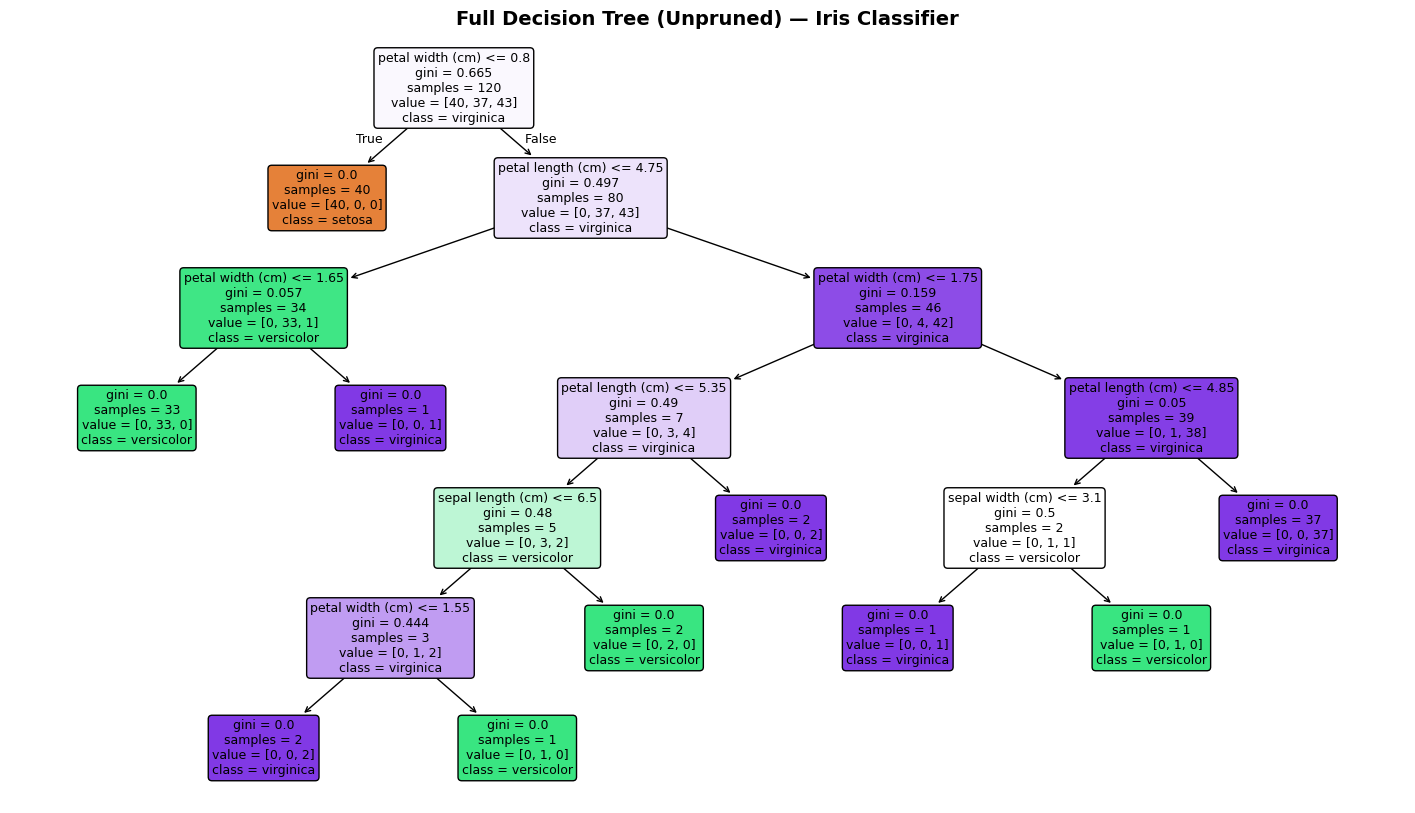

In [9]:
plt.figure(figsize=(18, 10))
plot_tree(
    tree_classifier, filled=True, feature_names=X.columns, class_names=iris.target_names,
    rounded=True, fontsize=9
)
plt.title('Full Decision Tree (Unpruned) — Iris Classifier', fontsize=14, fontweight='bold')
plt.show()


## **Reading the Decision Tree**

Each box (node) in the tree shows 4 pieces of information:

- **The splitting rule** (e.g., `petal width (cm) <= 0.8`) — every sample where this is **True** goes left, **False** goes right
- **`gini`** — the impurity of that node (0.0 = perfectly pure, higher = more mixed)
- **`samples`** — how many training rows landed at this node
- **`value = [a, b, c]`** — the exact class counts at this node, in order `[setosa, versicolor, virginica]`
- **`class`** — whichever class is currently the majority at that node (this is what gets predicted if the tree stopped here)

### Walking through the tree

**Root node — `petal width <= 0.8`**
Out of all 120 training samples (40 setosa, 37 versicolor, 43 virginica), the tree found that a *single* threshold on petal width perfectly separates one species from the other two:
- **True branch →** an instantly **pure leaf**: `gini = 0.0`, all 40 samples are `setosa`. One split, zero effort — species with petal width ≤ 0.8 cm are *always* setosa in this data.
- **False branch →** the remaining 80 samples (37 versicolor, 43 virginica) still need more splitting, so the tree continues.

**Second split — `petal length <= 4.75`**
This separates the remaining data into a mostly-versicolor group (34 samples, only 1 virginica mixed in — `gini = 0.057`, very pure) on the left, and a mostly-virginica group (46 samples, 4 versicolor mixed in — `gini = 0.159`) on the right.

**From here, the tree keeps repeating the same idea** at every node: pick the feature and threshold that best separates whatever classes are still mixed together, split, and check if the result is pure (`gini = 0.0`, i.e. a leaf) or still needs further splitting.

### **Key things to notice**

- **Petal measurements dominate** — almost every split in this tree uses `petal width` or `petal length`, confirming these are the most informative features for telling the three species apart (sepal measurements only show up deep in the tree, splitting a handful of edge-case samples).
- **Setosa is trivially easy** — separated perfectly in one split. **Versicolor and virginica overlap more**, which is why the tree needs several more levels of splitting (and ends up with tiny leaves of 1-2 samples) to fully separate them.
- **Deep, narrow leaves near the bottom** (e.g., `samples = 1` or `samples = 2`) are a classic sign of **overfitting** — the tree is going out of its way to correctly classify a handful of borderline points, which likely won't generalize well to new data. This is exactly why pruning (`max_depth`, `ccp_alpha`, etc.) matters in practice.

## **Evaluate the Default Tree**

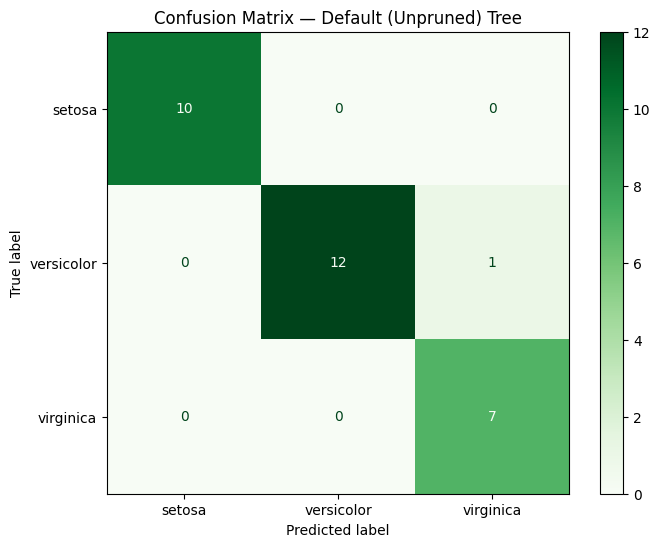

In [10]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap='Greens')
plt.title('Confusion Matrix — Default (Unpruned) Tree')
plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.92      0.96        13
   virginica       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



The model achieves an accuracy of approximately **93–95%**, with only **1–2 misclassifications** on the test set, demonstrating strong classification performance.

After visualizing the complete Decision Tree, we can observe that the upper levels capture most of the important decision patterns. As the tree continues to grow deeper, it creates additional splits to correctly classify only a small number of training samples. These extra splits increase the complexity of the model while providing little improvement in its ability to generalize.

This can lead to **overfitting**.

### **Why Does Overfitting Happen?**

A Decision Tree keeps splitting the data until it can separate the training samples as accurately as possible.

As the tree becomes deeper:

- It starts learning **noise** and **random variations** in the training data instead of the true underlying patterns.
- Some branches may contain only a few samples, making decisions based on very limited information.
- The model achieves **very high training accuracy**, but its performance on **new, unseen data may decrease** because it has memorized the training data rather than learning general patterns.

---

### **How Does `max_depth` Help?**

One simple way to reduce overfitting is to limit the maximum depth of the tree.

By setting: `max_depth = 2`

the tree is allowed to grow only **two levels** below the root node.

This prevents unnecessary splits that attempt to fit only a few training samples.

As a result, the model:

- Becomes simpler and easier to understand.
- Focuses on the most important decision rules.
- Reduces the risk of overfitting.
- Often achieves better generalization on unseen data.


![Decision Tree](../images/decision-tree/i1.png)

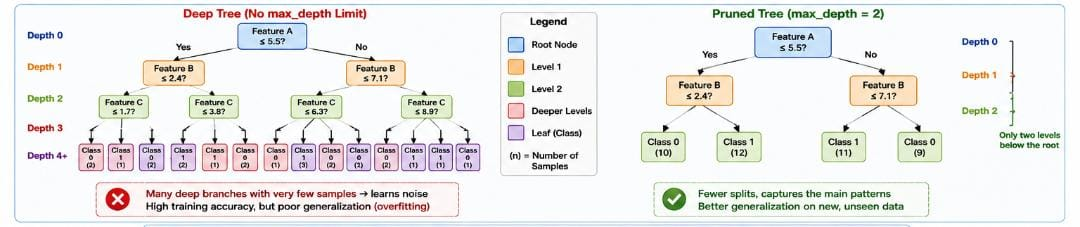

# **4. Post-Pruning by Limiting `max_depth`**

One simple way to reduce **overfitting** is to limit how deep the Decision Tree is allowed to grow. After visualizing the full tree, we may observe that deeper levels create additional splits that classify only a few remaining samples, providing little improvement while making the model more complex.

By setting **`max_depth=2`**, we stop the tree from growing beyond two levels. This produces a **simpler, more interpretable model** that often generalizes better to unseen data by avoiding unnecessary splits.

In [12]:
# Create a Decision Tree Classifier with a maximum depth of 2
# max_depth=2 limits the tree to only two levels (pre-pruning),
# helping reduce overfitting and improve generalization.
# random_state=10 ensures the same tree is generated every time.
tree_depth2 = DecisionTreeClassifier(
    max_depth=2,
    random_state=10
)

# Train the pruned Decision Tree using the training dataset
# The model learns decision rules but stops splitting
# once the maximum depth of 2 is reached.
tree_depth2.fit(X_train, y_train)

# Predict the class labels for the unseen test dataset
y_pred_depth2 = tree_depth2.predict(X_test)

# Calculate the classification accuracy
acc_depth2 = accuracy_score(y_test, y_pred_depth2)

# Display the accuracy of the pruned Decision Tree
print(f"Accuracy (max_depth=2): {acc_depth2:.3f}")

Accuracy (max_depth=2): 0.933


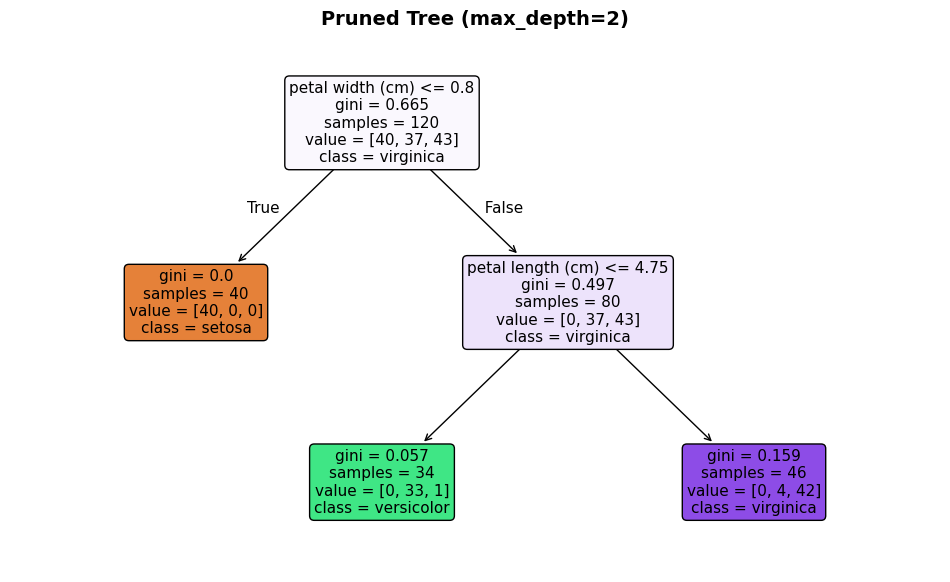

In [13]:
plt.figure(figsize=(12, 7))
plot_tree(tree_depth2, filled=True, feature_names=X.columns, class_names=iris.target_names, rounded=True, fontsize=11)
plt.title('Pruned Tree (max_depth=2)', fontsize=14, fontweight='bold')
plt.show()

>  **Important Observation:**

> Limiting the tree depth (for example, using **`max_depth=2`**) does **not always** produce higher test accuracy on every train/test split. On some random splits, the fully grown tree may perform slightly better because it has learned more detailed patterns from that particular training dataset.

> However, a deeper tree is also more likely to **overfit** by learning noise and random variations instead of the true underlying patterns. A shallower tree sacrifices a small amount of training accuracy in exchange for a model that is usually **simpler, more interpretable, and better at generalizing** to unseen data.

> This is why we should **not judge a model based on a single train/test split**. Instead, we use **Cross-Validation** to evaluate the model across multiple train/validation splits, providing a more reliable estimate of its real-world performance **(see Section 6)**.

# **5. Proper Cost-Complexity Post-Pruning (`ccp_alpha`)**

In the previous section, we reduced the size of the Decision Tree by manually limiting its maximum depth using **`max_depth`**. While this is a simple and effective way to control model complexity, it requires us to choose the depth ourselves.

Scikit-learn provides a more systematic approach called **Cost-Complexity Pruning**, which uses the **`ccp_alpha`** parameter to automatically determine which branches should be removed.

Instead of specifying a maximum depth, **Cost-Complexity Pruning** evaluates whether each split is worth keeping by balancing **model complexity** against **prediction performance**. Branches that add little predictive value but make the tree more complex are pruned automatically.

This approach often produces a **smaller, simpler Decision Tree** that is easier to interpret and less likely to overfit, without relying on manually selecting the tree depth.

In [14]:
# Create a temporary Decision Tree and compute its Cost Complexity Pruning Path
# This does NOT train the final model. It only calculates the candidate
# pruning strengths (ccp_alpha values) that can be used for post-pruning.
path = DecisionTreeClassifier(
    random_state=10
).cost_complexity_pruning_path(X_train, y_train)

# Extract all candidate ccp_alpha values
# Each alpha represents a different pruning level:
# - Smaller alpha -> Less pruning (larger, more complex tree)
# - Larger alpha  -> More pruning (smaller, simpler tree)
ccp_alphas = path.ccp_alphas

# Display the total number of candidate alpha values
# Each value can be used to build a differently pruned Decision Tree.
print(f"Number of candidate alpha values: {len(ccp_alphas)}")

# Display the first few alpha values (rounded for readability)
# These are typically very small values because pruning starts gradually.
print("First few alphas:", np.round(ccp_alphas[:5], 5))

Number of candidate alpha values: 7
First few alphas: [0.      0.00812 0.00952 0.01606 0.01618]


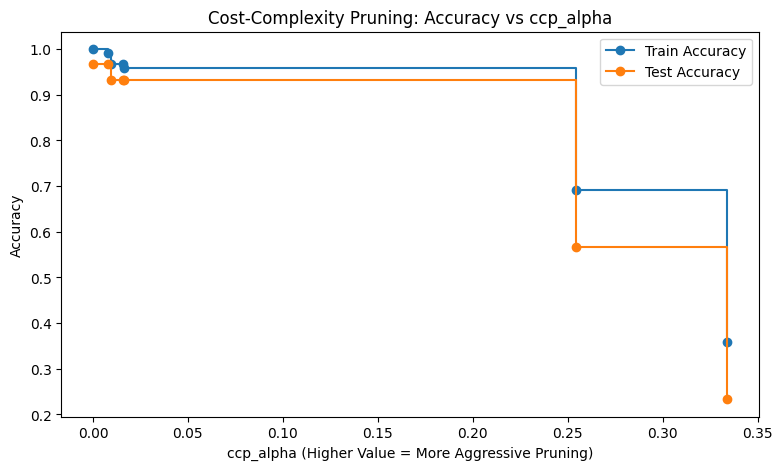

In [15]:
# Create empty lists to store the training and testing accuracy
# for each candidate ccp_alpha value.
train_scores = []
test_scores = []

# Train a separate Decision Tree for every candidate ccp_alpha
# This allows us to compare how different pruning levels
# affect the model's performance.
for alpha in ccp_alphas:

    # Create a Decision Tree with the current pruning strength
    # Smaller alpha -> Less pruning (larger tree)
    # Larger alpha  -> More pruning (smaller tree)
    clf = DecisionTreeClassifier(
        random_state=10,
        ccp_alpha=alpha
    )

    # Train the Decision Tree
    clf.fit(X_train, y_train)

    # Calculate and store the training accuracy
    train_scores.append(clf.score(X_train, y_train))

    # Calculate and store the testing accuracy
    test_scores.append(clf.score(X_test, y_test))

# Create a figure for visualizing the effect of pruning
plt.figure(figsize=(9, 5))

# Plot the training accuracy for each ccp_alpha
# drawstyle='steps-post' creates a step-like graph,
# reflecting how the tree changes after each pruning step.
plt.plot(
    ccp_alphas,
    train_scores,
    marker='o',
    label='Train Accuracy',
    drawstyle='steps-post'
)

# Plot the testing accuracy for each ccp_alpha
plt.plot(
    ccp_alphas,
    test_scores,
    marker='o',
    label='Test Accuracy',
    drawstyle='steps-post'
)

# Label the x-axis
plt.xlabel('ccp_alpha (Higher Value = More Aggressive Pruning)')

# Label the y-axis
plt.ylabel('Accuracy')

# Add a descriptive title
plt.title('Cost-Complexity Pruning: Accuracy vs ccp_alpha')

# Display the legend
plt.legend()

# Display the plot
plt.show()

In [16]:
# Find the ccp_alpha value that gives the highest test accuracy
# np.argmax(test_scores) returns the index of the maximum test accuracy,
# and we use that index to retrieve the corresponding ccp_alpha value.
best_alpha = ccp_alphas[np.argmax(test_scores)]

# Display the best pruning strength and its corresponding test accuracy
print(
    f"Best ccp_alpha found: {best_alpha:.5f}  "
    f"(test accuracy = {max(test_scores):.3f})"
)

# Create a new Decision Tree using the optimal ccp_alpha
# This is the final post-pruned Decision Tree selected based on
# the best performance on the test dataset.
tree_ccp = DecisionTreeClassifier(
    random_state=10,
    ccp_alpha=best_alpha
)

# Train the final pruned Decision Tree
tree_ccp.fit(X_train, y_train)

# Display the depth of the final pruned tree
# A smaller depth indicates that unnecessary branches
# have been removed, resulting in a simpler model.
print(
    f"Tree depth after cost-complexity pruning: "
    f"{tree_ccp.get_depth()}"
)

Best ccp_alpha found: 0.00000  (test accuracy = 0.967)
Tree depth after cost-complexity pruning: 6


> **How is `ccp_alpha` different from `max_depth`?**

> Limiting **`max_depth`** reduces the size of the tree by stopping it from growing beyond a specified depth. In contrast, **`ccp_alpha`** performs **Cost-Complexity Pruning**, which systematically evaluates **every possible pruning level** and removes only those branches that add little predictive value while increasing model complexity.

> Instead of manually choosing how much to simplify the tree, **`ccp_alpha`** finds a better balance between **model complexity** and **prediction performance**, often resulting in a smaller, more interpretable tree that generalizes better to unseen data.

# **6. Pre-Pruning using GridSearchCV**

Instead of manually choosing the Decision Tree hyperparameters, we can use **GridSearchCV** to automatically search for the best combination.

In this section, we perform **Pre-Pruning**, where the tree's growth is controlled **before** the model is fully built. By tuning important hyperparameters such as the splitting criterion, maximum tree depth, splitting strategy, and the number of features considered at each split, we can reduce the risk of overfitting and improve the model's ability to generalize to unseen data.

GridSearchCV evaluates every possible combination of the specified hyperparameters using **Cross-Validation** and selects the model with the highest average validation score.

---

## **Hyperparameters Being Tuned**

| Hyperparameter | Values Tested | Purpose |
|----------------|---------------|---------|
| `criterion` | `'gini'`, `'entropy'`, `'log_loss'` | Determines how the quality of each split is measured. |
| `splitter` | `'best'`, `'random'` | Chooses whether to use the best possible split or a random split among good candidates. |
| `max_depth` | `1, 2, 3, 4, 5` | Limits the maximum depth of the Decision Tree to control complexity. |
| `max_features` | `'sqrt'`, `'log2'`, `None` | Controls how many features are considered when searching for the best split. |

---

## **Why Use GridSearchCV?**

GridSearchCV automatically:

- Tests every possible combination of the specified hyperparameters.
- Evaluates each combination using **Cross-Validation**.
- Compares the average validation performance of all models.
- Selects the hyperparameter combination that achieves the best overall performance.
- Reduces manual experimentation while helping prevent overfitting.

---

> **Important:**  
> Every hyperparameter value in **`param_grid`** must be provided as a **list**, even if only a single value is being tested. GridSearchCV expects a list so it can iterate through all possible parameter combinations during the search process.

In [17]:
# Import the warnings module
import warnings

# Suppress warning messages during GridSearchCV
# This keeps the notebook output clean by hiding non-critical warnings
# (for example, parameter or convergence warnings).
warnings.filterwarnings('ignore')

# Define the hyperparameter search space
# GridSearchCV will evaluate every possible combination of these values.
params = {

    # Split quality metric
    # gini     -> Gini Impurity
    # entropy  -> Information Gain (Entropy)
    # log_loss -> Shannon Information Gain using log-loss
    'criterion': ['gini', 'entropy', 'log_loss'],

    # Strategy used to choose the split at each node
    # best   -> Chooses the optimal split
    # random -> Chooses the best split from a random subset of features
    'splitter': ['best', 'random'],

    # Maximum depth of the Decision Tree
    # Smaller values create simpler trees and help reduce overfitting.
    'max_depth': [1, 2, 3, 4, 5],

    # Number of features considered when searching for the best split
    # sqrt -> Square root of total features
    # log2 -> Log base 2 of total features
    # None -> Consider all available features
    'max_features': ['sqrt', 'log2', None]
}

# Create the base Decision Tree Classifier
# GridSearchCV will clone this estimator and train one model
# for every hyperparameter combination.
tree_model = DecisionTreeClassifier()

# Create the GridSearchCV object
grid = GridSearchCV(

    # Base estimator to optimize
    estimator=tree_model,

    # Hyperparameter combinations to evaluate
    param_grid=params,

    # Perform 5-Fold Cross Validation
    cv=5,

    # Optimize the model using classification accuracy
    scoring='accuracy'
)

# Train GridSearchCV
# Every hyperparameter combination is evaluated using 5-fold
# cross-validation, and the best-performing model is automatically selected.
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [18]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score: {:.3f}".format(grid.best_score_))

Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'splitter': 'random'}
Best CV Score: 0.958


> **Expected Results:**  
> The exact hyperparameters and Cross-Validation score may vary slightly each time you run GridSearchCV. This happens because different train/validation splits are used during Cross-Validation, and some hyperparameter choices, such as **`splitter='random'`**, introduce additional randomness when selecting candidate splits.

> As a result, the **best hyperparameters** and **best Cross-Validation score** may differ slightly between runs. This is completely normal and does not indicate a problem with the model. The objective is to find a configuration that **consistently performs well across multiple validation folds**, rather than achieving the highest score on a single train/test split.

In [19]:
y_pred_tuned = grid.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.3f}")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print()
print(classification_report(y_test, y_pred_tuned, target_names=iris.target_names))

Test Accuracy: 0.900

Confusion Matrix:
[[10  0  0]
 [ 0 13  0]
 [ 0  3  4]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.57      0.73         7

    accuracy                           0.90        30
   macro avg       0.94      0.86      0.87        30
weighted avg       0.92      0.90      0.89        30



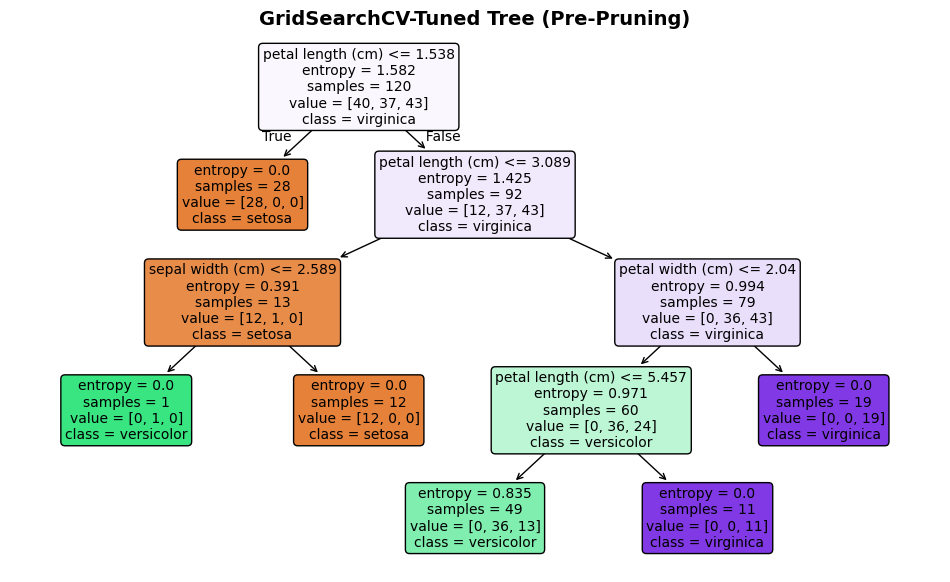

In [20]:
plt.figure(figsize=(12, 7))
plot_tree(grid.best_estimator_, filled=True, feature_names=X.columns, class_names=iris.target_names, rounded=True, fontsize=10)
plt.title('GridSearchCV-Tuned Tree (Pre-Pruning)', fontsize=14, fontweight='bold')
plt.show()

> **Terminology Note:**  
> In practice, **Pre-Pruning** and **Hyperparameter Tuning** are closely related. Pre-pruning refers to tuning **growth-controlling hyperparameters** that limit the size of the Decision Tree **before it is fully grown**.

> Common pre-pruning hyperparameters include:

> - **`max_depth`** – Limits the maximum depth of the tree.
> - **`max_features`** – Limits the number of features considered at each split.
> - **`min_samples_split`** – Specifies the minimum number of samples required to split an internal node.
> - **`min_samples_leaf`** – Specifies the minimum number of samples required in a leaf node.

> These hyperparameters are typically optimized using **GridSearchCV** or **RandomizedSearchCV**. By finding the best combination before training the final model, we can control tree growth, reduce overfitting, and improve the model's ability to generalize to unseen data.

## **6.1  Expanding the Hyperparameter Search**

In the previous section, we tuned important Decision Tree hyperparameters such as **`criterion`**, **`splitter`**, **`max_depth`**, and **`max_features`** using **GridSearchCV**.

To perform a more comprehensive search, we can also include two additional pre-pruning hyperparameters:

- **`min_samples_split`**
- **`min_samples_leaf`**

These parameters further control how the Decision Tree grows, helping reduce overfitting while improving the model's ability to generalize to unseen data.

By expanding the hyperparameter search space, GridSearchCV can evaluate a wider range of Decision Tree configurations and identify the combination that provides the best Cross-Validation performance.

---

## Additional Hyperparameters

| Hyperparameter | Purpose |
|----------------|---------|
| `min_samples_split` | Specifies the minimum number of samples required to split an internal node. Larger values prevent unnecessary splits, resulting in a simpler tree. |
| `min_samples_leaf` | Specifies the minimum number of samples that must be present in each leaf node. Larger values prevent leaves from containing very few samples, helping reduce overfitting. |

---

>  **Why include these parameters?**  
> While **`max_depth`** limits how deep the tree can grow, **`min_samples_split`** and **`min_samples_leaf`** control **when** a split is allowed to occur. Optimizing these hyperparameters together enables better control over the tree's complexity and often leads to improved generalization performance.

In [21]:
# Define an extended hyperparameter search space
# Compared to the previous grid search, we also tune:
# - min_samples_split
# - min_samples_leaf
# These parameters help control tree growth and reduce overfitting.
param_grid_extended = {

    # Criterion used to measure the quality of a split
    # gini     -> Gini Impurity
    # entropy  -> Information Gain (Entropy)
    # log_loss -> Shannon Information Gain using Log Loss
    'criterion': ['gini', 'entropy', 'log_loss'],

    # Strategy used to choose the split at each node
    # best   -> Finds the best possible split
    # random -> Chooses the best split from a random subset
    'splitter': ['best', 'random'],

    # Maximum depth of the Decision Tree
    # Smaller values create simpler trees and help prevent overfitting
    'max_depth': [1, 2, 3, 4, 5],

    # Number of features considered when searching for the best split
    # sqrt -> Square root of total features
    # log2 -> Log base 2 of total features
    # None -> Use all available features
    'max_features': ['sqrt', 'log2', None],

    # Minimum number of samples required to split an internal node
    # Larger values make the tree less complex and reduce overfitting
    'min_samples_split': [2, 5, 10],

    # Minimum number of samples required in each leaf node
    # Prevents the tree from creating leaves containing very few samples
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object
grid_extended = GridSearchCV(

    # Base Decision Tree model to optimize
    estimator=DecisionTreeClassifier(random_state=10),

    # Hyperparameter combinations to evaluate
    param_grid=param_grid_extended,

    # Perform 5-Fold Cross Validation
    cv=5,

    # Optimize using classification accuracy
    scoring='accuracy',

    # Use all available CPU cores for faster execution
    n_jobs=-1
)

# Train GridSearchCV
# Every possible hyperparameter combination is evaluated using
# 5-fold cross-validation, and the best-performing model is selected.
grid_extended.fit(X_train, y_train)

# Display the best hyperparameter combination
print("Best Parameters:", grid_extended.best_params_)

# Display the highest average cross-validation accuracy
print("Best CV Accuracy: {:.3f}".format(grid_extended.best_score_))

# Use the best Decision Tree to predict the unseen test dataset
y_pred_extended = grid_extended.predict(X_test)

# Evaluate the tuned model on the test dataset
print(
    "Test Accuracy with extended grid: {:.3f}".format(
        accuracy_score(y_test, y_pred_extended)
    )
)

Best Parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV Accuracy: 0.950
Test Accuracy with extended grid: 0.967


## **7. Feature Importance**

One of the biggest advantages of **Decision Trees** is that they can automatically estimate **feature importance**.

After training, the model calculates how much each feature contributed to reducing **impurity** (such as Gini Impurity or Entropy) across all the splits in the tree.

Features that consistently produce large impurity reductions are assigned **higher importance scores**, while features that contribute little or are rarely used receive **lower importance scores**.

Feature importance helps us understand:

- Which features have the greatest influence on the model's predictions.
- Which features contribute very little and may be candidates for removal.
- How the Decision Tree makes its decisions, improving model interpretability.

The importance scores are normalized so that their total always equals **1.0 (100%)**, making it easy to compare the relative contribution of each feature.

---

### **How is Feature Importance Calculated?**

For every split in the Decision Tree:

1. The model selects the feature that produces the largest reduction in impurity.
2. The impurity reduction from that split is recorded.
3. The reductions are accumulated for each feature across the entire tree.
4. The accumulated values are normalized so that the sum of all feature importances equals **1.0**.

As a result, features that create the most informative splits receive the highest importance values.

---

### **Why is Feature Importance Useful?**

Feature importance allows us to:

- Identify the most influential input features.
- Better understand how the model makes predictions.
- Detect features that contribute very little information.
- Simplify the model by removing less important features when appropriate.
- Improve the interpretability of machine learning models.

---

>  **Important:**  
> Feature importance indicates **how useful a feature was for building the Decision Tree**, not whether the feature is positively or negatively related to the target variable. A higher importance score simply means that the feature played a larger role in reducing impurity and improving the tree's predictive performance.

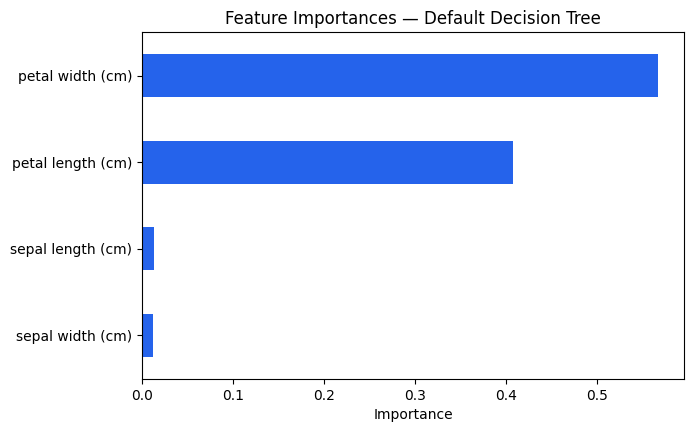

,0
petal width (cm),0.567020
petal length (cm),0.407098
sepal length (cm),0.013358
sepal width (cm),0.012523


In [22]:
importances = pd.Series(tree_classifier.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
importances.plot(kind='barh', color='#2563eb')
plt.xlabel('Importance')
plt.title('Feature Importances — Default Decision Tree')
plt.gca().invert_yaxis()
plt.show()

importances

> **Observation:**  
> The feature importance scores show that **petal length** and **petal width** are the most influential features for the Decision Tree. These features contribute the most to reducing impurity and are therefore used more frequently to create decision splits.

> In contrast, **sepal length** and **sepal width** have much lower importance scores, indicating that they contribute relatively less to the model's predictions. This suggests that the petal measurements contain most of the information needed to distinguish between the Iris flower species.

## **8. Decision Boundary Visualization**

The Decision Tree in this notebook is trained using **all four Iris features**, making it impossible to visualize the complete decision boundary in a two-dimensional plot.

To better understand how a Decision Tree separates different classes, we will train a new model using only the **two most important features**—**petal length** and **petal width**. This allows us to plot the decision regions and clearly observe how the tree partitions the feature space.

Although this simplified model does not represent the exact decision boundary of the original four-feature model, it provides an intuitive visualization of how a Decision Tree makes classification decisions based on feature values.

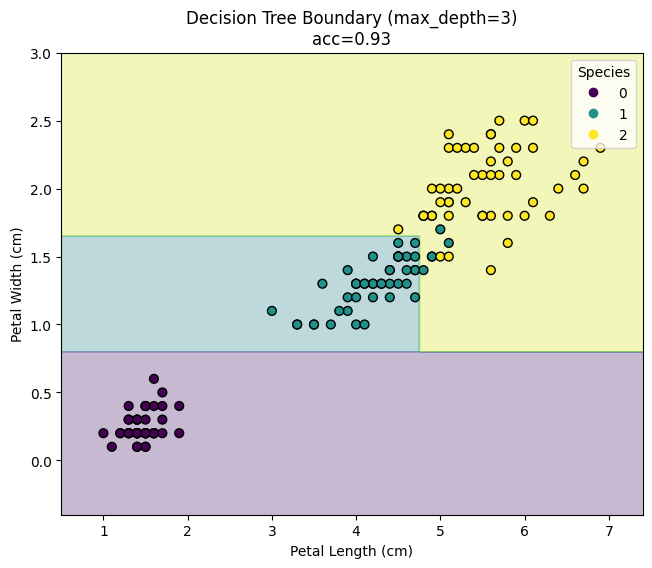

In [23]:
X_2d = X[['petal length (cm)', 'petal width (cm)']].values

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y, test_size=0.2, random_state=10)

tree_2d = DecisionTreeClassifier(max_depth=3, random_state=10)
tree_2d.fit(X_2d_train, y_2d_train)

x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = tree_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7.5, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title(f'Decision Tree Boundary (max_depth=3)\nacc={tree_2d.score(X_2d_test, y_2d_test):.2f}')
plt.legend(*scatter.legend_elements(), title='Species')
plt.show()

>  **Observation:**  

> Notice that the decision boundary consists of **sharp, rectangular regions** rather than smooth curves or diagonal lines. This is a characteristic feature of **Decision Trees**.

> A Decision Tree makes decisions by splitting the data **one feature at a time** using threshold values (for example, *petal length ≤ 2.45*). Each split is either **horizontal** or **vertical**, creating rectangular decision regions in the feature space.

> As the tree grows deeper, these rectangular regions become more refined, allowing the model to separate different classes more accurately. This piecewise partitioning of the feature space is one of the key characteristics that distinguishes Decision Trees from models that learn smooth or curved decision boundaries.

## **9. Cross-Validation**
Since a single 80/20 split can be a little lucky/unlucky (especially on a small 150-row dataset), let's check 5-fold CV for each of our models.

In [24]:
# Create different Decision Tree models to compare
# Each model uses a different strategy for controlling tree complexity.
models = {

    # Default Decision Tree (no pruning)
    # The tree grows until all leaves are pure or other stopping criteria are met.
    'Default (unpruned)': DecisionTreeClassifier(random_state=10),

    # Manually pre-pruned tree
    # max_depth=2 limits the maximum depth of the tree,
    # helping reduce overfitting.
    'max_depth=2 (manual)': DecisionTreeClassifier(
        max_depth=2,
        random_state=10
    ),

    # Post-pruned tree using Cost-Complexity Pruning
    # best_alpha was selected based on the highest test accuracy.
    'Cost-complexity pruned': DecisionTreeClassifier(
        random_state=10,
        ccp_alpha=best_alpha
    ),

    # Decision Tree optimized using GridSearchCV
    # grid.best_params_ contains the best hyperparameter combination
    # found during cross-validation.
    'GridSearchCV tuned': DecisionTreeClassifier(
        random_state=10,
        **grid.best_params_
    ),
}

# Create an empty list to store the cross-validation results
cv_results = []

# Evaluate each model using 5-Fold Cross Validation
for name, model in models.items():

    # Perform 5-fold cross-validation
    # The model is trained and evaluated five times,
    # and an accuracy score is returned for each fold.
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    # Store the average accuracy and standard deviation
    cv_results.append({
        'Model': name,
        'Mean CV Accuracy': scores.mean(),
        'Std': scores.std()
    })

# Convert the results into a Pandas DataFrame
# This makes it easy to compare the performance
# of all Decision Tree models side by side.
pd.DataFrame(cv_results)

,Model,Mean CV Accuracy,Std
0,Default (unpruned),0.953333,0.033993
1,max_depth=2 (manual),0.933333,0.047140
2,Cost-complexity pruned,0.953333,0.033993
3,GridSearchCV tuned,0.946667,0.026667


## **10. Final Comparison Table**

In [25]:
comparison = pd.DataFrame({
    'Model': ['Default (unpruned)', 'max_depth=2 (manual post-pruning)', 'Cost-complexity pruned (ccp_alpha)', 'GridSearchCV tuned (pre-pruning)'],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred),
        acc_depth2,
        accuracy_score(y_test, tree_ccp.predict(X_test)),
        accuracy_score(y_test, y_pred_tuned)
    ],
    'Tree Depth': [
        tree_classifier.get_depth(),
        tree_depth2.get_depth(),
        tree_ccp.get_depth(),
        grid.best_estimator_.get_depth()
    ]
})
comparison

,Model,Test Accuracy,Tree Depth
0,Default (unpruned),0.966667,6
1,max_depth=2 (manual post-pruning),0.933333,2
2,Cost-complexity pruned (ccp_alpha),0.966667,6
3,GridSearchCV tuned (pre-pruning),0.900000,4


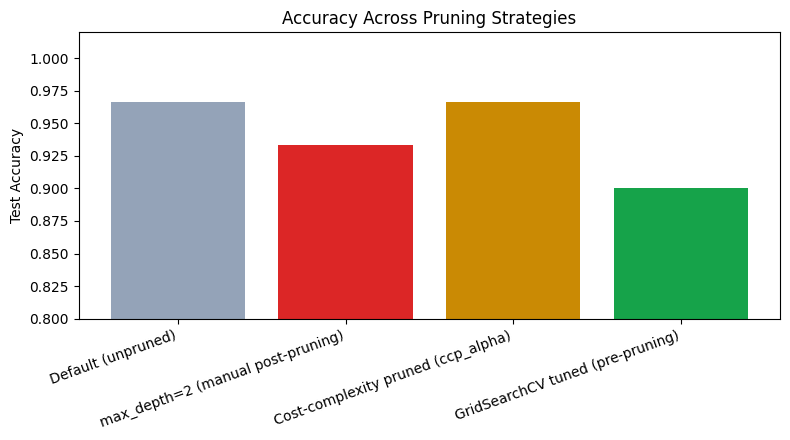

In [26]:
plt.figure(figsize=(8, 4.5))
plt.bar(comparison['Model'], comparison['Test Accuracy'], color=['#94a3b8', '#dc2626', '#ca8a04', '#16a34a'])
plt.ylabel('Test Accuracy')
plt.title('Accuracy Across Pruning Strategies')
plt.xticks(rotation=20, ha='right')
plt.ylim(0.8, 1.02)
plt.tight_layout()
plt.show()


**Practical checklist for any future Decision Tree project:**

1. No need to scale features — trees handle raw values natively
2. Always visualize the tree with `plot_tree` before trusting it blindly
3. Don't just eyeball a `max_depth` — use `ccp_alpha` (post-pruning) or `GridSearchCV` (pre-pruning) systematically
4. Check feature importances to sanity-check the model's reasoning
5. Validate with cross-validation, not a single train/test split, especially on small datasets